# Sentiment and Thematic Analysis

In [28]:
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import torch
import sys
import os
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import scripts.sentiment

sys.path.append(
    os.path.abspath("..")
)

from scripts.load import (
    load_files
)
from scripts.sentiment import (
    sentiment_analysis
)
from scripts.preprocessing import (
    clean_text
)
from scripts.theme import (
    assign_theme
)

df = load_files()
all_reviews_df = pd.concat(
    [df["abyssinia"],df["cbe"],df["dashen"]],
    ignore_index=True
)

In [4]:
nltk.download('stopwords')

stop_words = stopwords.words('english')
stop_words = list(set(stop_words).union(ENGLISH_STOP_WORDS))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\megde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Sentiment analysis using Transformers

In [25]:
sentiment_analysis(all_reviews_df)

Running Transformer Sentiment: 100%|██████████| 94/94 [01:11<00:00,  1.32it/s]


Transformer Sentiment Distribution:
transformer_sentiment_label
POSITIVE    0.62
NEGATIVE    0.38
Name: proportion, dtype: float64


### Aggregating scores and visualizing sentiment

In [7]:
transformer_agg_sentiment = all_reviews_df.groupby(['bank', 'rating'])['transformer_sentiment_score'].mean().unstack()
transformer_agg_sentiment

rating,1,2,3,4,5
bank,,,,,
Bank of Abyssinia,-0.826938,-0.563670,-0.222430,0.051178,0.609776
Commercial Bank of Ethiopia,-0.555399,-0.665565,-0.382954,-0.039735,0.731953
Dashen Bank,-0.770299,-0.571110,-0.542542,0.390210,0.719811


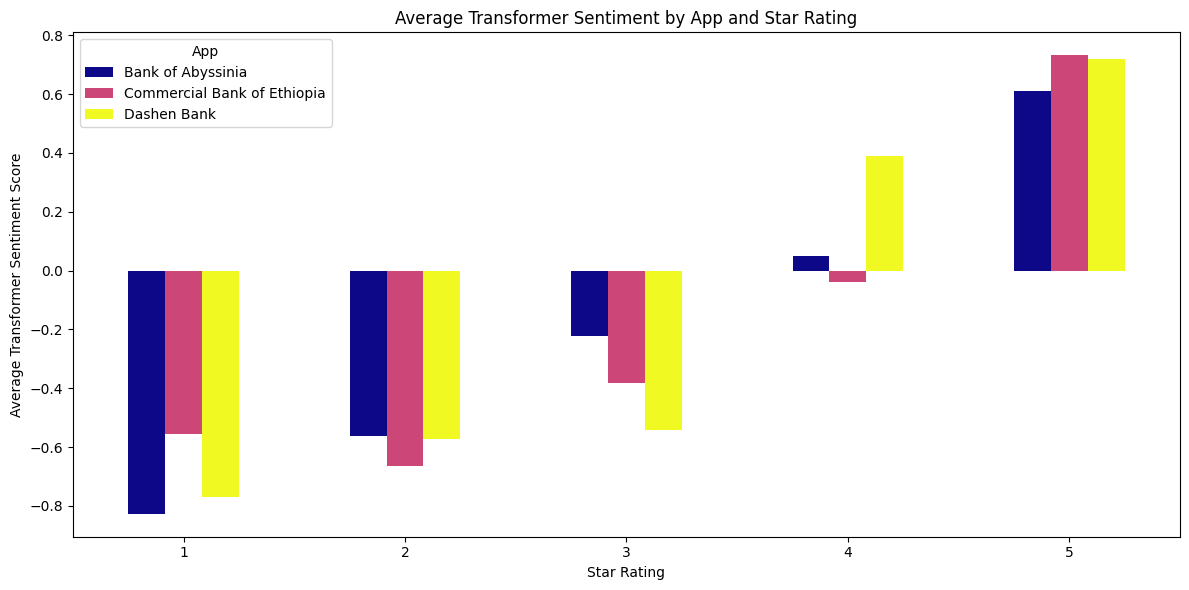

In [8]:
transformer_agg_sentiment.T.plot(kind='bar', figsize=(12, 6), colormap='plasma')
plt.title('Average Transformer Sentiment by App and Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Transformer Sentiment Score')
plt.xticks(rotation=0)
plt.legend(title='App')
plt.tight_layout()
plt.show()

### Thematic Analysis

In [ ]:
all_reviews_df['clean_review'] = all_reviews_df['review'].astype(str).apply(clean_text)


In [11]:
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    stop_words='english',
    min_df=2
)
for bank, df in all_reviews_df.groupby("bank"):
    print("\n", bank)
    X = vectorizer.fit_transform(df['clean_review'])
    keywords = vectorizer.get_feature_names_out()
    scores = X.sum(axis=0).A1
    top = sorted(zip(keywords, scores), key=lambda x: x[1], reverse=True)[:10]
    print(top)


 Bank of Abyssinia
[('good', np.float64(75.64784066604048)), ('app', np.float64(43.47986027508901)), ('best', np.float64(24.30899985463933)), ('nice', np.float64(20.166798732288296)), ('boa', np.float64(16.242990745256048)), ('bank', np.float64(11.909815004003997)), ('working', np.float64(11.275574956435841)), ('work', np.float64(8.76210545271309)), ('banking', np.float64(8.528146019522662)), ('fast', np.float64(8.526461584579575))]

 Commercial Bank of Ethiopia
[('good', np.float64(89.43988054520356)), ('app', np.float64(36.68809469598462)), ('nice', np.float64(28.334395120128388)), ('best', np.float64(27.59636633210067)), ('ok', np.float64(20.0)), ('cbe', np.float64(11.593201231698206)), ('like', np.float64(10.361828826621535)), ('nice app', np.float64(8.92584816328547)), ('working', np.float64(8.835836986157767)), ('bank', np.float64(8.44037922434103))]

 Dashen Bank
[('good', np.float64(56.12414755831467)), ('app', np.float64(42.00829859631348)), ('nice', np.float64(24.88334829998

In [ ]:
all_reviews_df['theme'] = all_reviews_df['clean_review'].apply(assign_theme)
all_reviews_df['theme'].value_counts()

theme
Other                 1311
UI/UX                   74
Transaction Issues      49
Performance Issues      44
Account Issues          22
Name: count, dtype: int64

In [13]:
theme_sentiment = all_reviews_df.groupby('theme')['transformer_sentiment_score'].mean().sort_values()
theme_sentiment

theme
Performance Issues   -0.948125
Account Issues       -0.717341
Transaction Issues   -0.550490
Other                 0.317536
UI/UX                 0.460998
Name: transformer_sentiment_score, dtype: float64

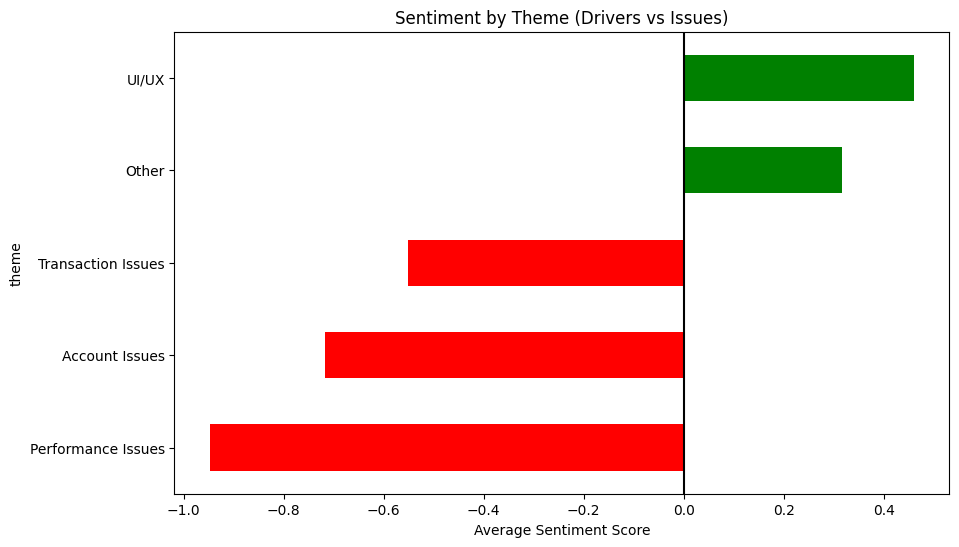

In [14]:

plt.figure(figsize=(10,6))

colors = ['red' if x < 0 else 'green' for x in theme_sentiment.values]

theme_sentiment.plot(kind='barh', color=colors)

plt.title("Sentiment by Theme (Drivers vs Issues)")
plt.xlabel("Average Sentiment Score")
plt.axvline(0, color='black')

plt.show()

In [15]:
for bank, df in all_reviews_df.groupby("bank"):
    print("\n", bank)
    print(df.groupby('theme')['transformer_sentiment_score'].mean())


 Bank of Abyssinia
theme
Account Issues       -0.719472
Other                 0.195168
Performance Issues   -0.987225
Transaction Issues   -0.997492
UI/UX                -0.616263
Name: transformer_sentiment_score, dtype: float64

 Commercial Bank of Ethiopia
theme
Account Issues       -0.999756
Other                 0.427868
Performance Issues   -0.802730
Transaction Issues   -0.391558
UI/UX                 0.540158
Name: transformer_sentiment_score, dtype: float64

 Dashen Bank
theme
Account Issues       -0.664942
Other                 0.329618
Performance Issues   -0.999682
Transaction Issues   -0.554903
UI/UX                 0.672864
Name: transformer_sentiment_score, dtype: float64


TF-IDF was used to extract common keywords and phrases from user reviews. Similar keywords were manually grouped into business-related themes such as Account Issues, Transaction Issues, Performance Issues and UI/UX. Reviews mentioning login problems, OTP failures, crashes, slow performance and failed transfers were categorized as pain points, while reviews mentioning ease of use and interface quality were grouped under UI/UX.

In [20]:
final_df = all_reviews_df[
    [
        'review_id',
        'review',
        'transformer_sentiment_label',
        'transformer_sentiment_score',
        'theme'
    ]
]

final_df = final_df.rename(columns={
    'review': 'review_text',
    'transformer_sentiment_label': 'sentiment_label',
    'transformer_sentiment_score': 'sentiment_score',
    'theme': 'identified_theme'
})

final_df.to_csv("../data/processed/final_reviews.csv", index=False)